# 02. Pair Generator v2 semantic controls: dataset-based comparison

Этот ноутбук сравнивает стратегии Pair Generator на фиксированном synthetic user dataset.

Сравниваем:

- `random` — v0 baseline;
- `uncertainty_axis` — v1;
- `semantic_control` — v2;
- `hybrid` — смесь random + semantic + axis.

Dataset заранее генерируется в `00_generate_synthetic_users_dataset.ipynb`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from personalization.state import FEATURE_NAMES_8D
from personalization.control_basis import CONTROL_NAMES_4D, CONTROL_BASIS_4D_TO_8D
from personalization.synthetic_dataset import (
    TARGET_MODES,
    USER_ARCHETYPES_8D,
    generate_synthetic_users_dataset,
    load_synthetic_users_dataset,
    save_synthetic_users_dataset,
    dataset_metadata,
)
from personalization.batch_eval import (
    DEFAULT_STRATEGIES,
    run_batch_on_dataset,
    summarize_by_strategy,
    win_rates_vs_baseline,
    save_batch_outputs,
)
from personalization.plotting import (
    plot_semantic_control_basis_heatmap,
    plot_semantic_control_influence,
    plot_intensity_distribution,
)
from personalization.analysis import (
    merge_sessions_with_user_metadata,
    summarize_by_group,
    winners_by_group,
    win_rates_vs_baseline_by_group,
    plot_group_metric_bars,
    plot_win_rate_bars,
)


## Загрузка dataset

Если dataset ещё не создан, ячейка ниже сгенерирует его автоматически.

In [2]:
DATASET_NAME = 'synthetic_users_v2'
DATASET_DIR = PROJECT_ROOT / 'outputs' / 'datasets'
DATASET_PATH = DATASET_DIR / f'{DATASET_NAME}.csv'
METADATA_PATH = DATASET_DIR / f'{DATASET_NAME}_metadata.json'

if not DATASET_PATH.exists():
    print('Dataset not found. Generating:', DATASET_PATH)
    dataset = generate_synthetic_users_dataset(
        n_per_mode=100,
        modes=TARGET_MODES,
        seed=42,
        noise_std=0.05,
        importance_sigma=0.35,
        target_max_abs=2.0,
        archetype_extreme_probability=0.30,
    )
    metadata = dataset_metadata(
        dataset_name=DATASET_NAME,
        n_per_mode=100,
        seed=42,
        noise_std=0.05,
        importance_sigma=0.35,
        target_max_abs=2.0,
        archetype_extreme_probability=0.30,
    )
    metadata['n_users_total'] = int(len(dataset))
    save_synthetic_users_dataset(dataset, DATASET_PATH, METADATA_PATH, metadata)
else:
    dataset = load_synthetic_users_dataset(DATASET_PATH)

dataset.head()

,user_id,target_mode,noise_std,z_sub_bass,z_bass,z_lowmid,z_warmth,z_presence,z_clarity,z_air,...,mix_warm,mix_bright,mix_v_shape,mix_mid_forward,mix_soft_dark,mix_detail_focused,mix_basshead,mix_extreme_vshape,mix_club_curve,mix_sparkle_lover
0,0,random8d,0.05,0.243774,-0.831987,0.600361,0.752452,-1.560828,-1.041744,0.102272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,random8d,0.05,0.295001,-0.767106,0.702760,-0.039941,-0.147890,-0.544744,0.978033,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,random8d,0.05,-0.409794,-0.651018,0.492784,0.903178,-0.091158,-0.672125,-0.659585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,random8d,0.05,0.543131,0.054063,0.231296,0.505031,-1.165725,-0.255737,-0.376298,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,random8d,0.05,0.568981,0.634678,-0.278980,-0.369881,0.686381,-0.153043,-1.020549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Проверка состава dataset

In [3]:
dataset.groupby('target_mode').size().to_frame('n_users')

,n_users
target_mode,
archetype8d,100
random8d,100
semantic4d,100


n_users
target_mode intensity_label         
archetype8d extreme               16
            mild                  20
            moderate              28
            strong                36
random8d    random               100
semantic4d  semantic             100

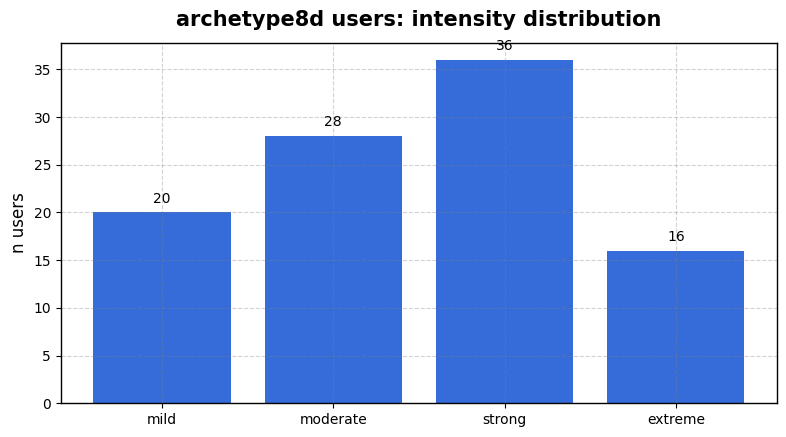

In [4]:
if 'intensity_label' in dataset.columns:
    display(dataset.groupby(['target_mode', 'intensity_label']).size().to_frame('n_users'))

archetype_users = dataset[dataset['target_mode'] == 'archetype8d'].copy()
if len(archetype_users) > 0:
    plot_intensity_distribution(archetype_users, title='archetype8d users: intensity distribution')
    plt.show()

## Semantic basis 4D → 8D

`semantic_control` двигает внутренний weighted 8D-вектор не по одной сырой оси, а через 4 музыкально осмысленных направления.

In [5]:
basis_df = pd.DataFrame(
    CONTROL_BASIS_4D_TO_8D,
    index=CONTROL_NAMES_4D,
    columns=FEATURE_NAMES_8D,
)
basis_df.round(3)

,sub_bass,bass,lowmid,warmth,presence,clarity,air,brightness
low_power,0.633,0.744,0.149,-0.037,0.000,0.000,0.000,-0.149
warmth_body,0.000,0.110,0.622,0.731,-0.146,-0.110,0.000,-0.183
presence_clarity,0.000,0.000,-0.146,-0.073,0.621,0.730,0.146,0.183
air_brightness,-0.106,-0.141,0.000,-0.106,0.070,0.317,0.704,0.598


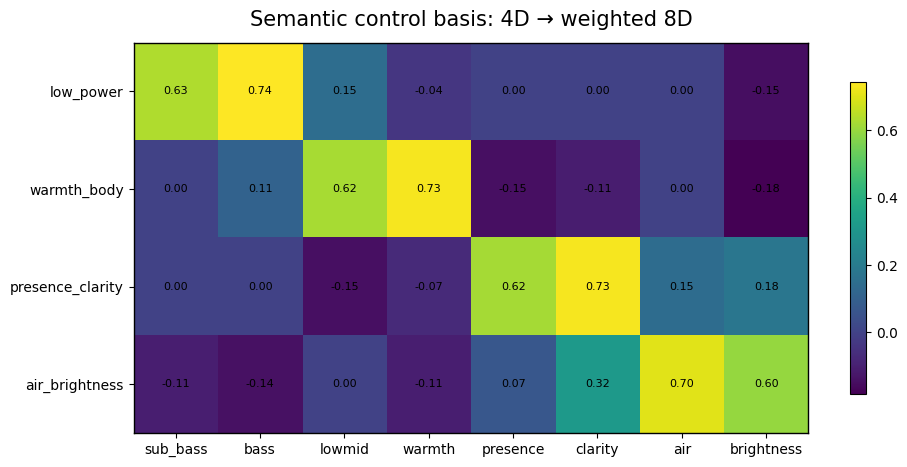

In [6]:
plot_semantic_control_basis_heatmap(
    CONTROL_BASIS_4D_TO_8D,
    CONTROL_NAMES_4D,
    FEATURE_NAMES_8D,
)
plt.show()

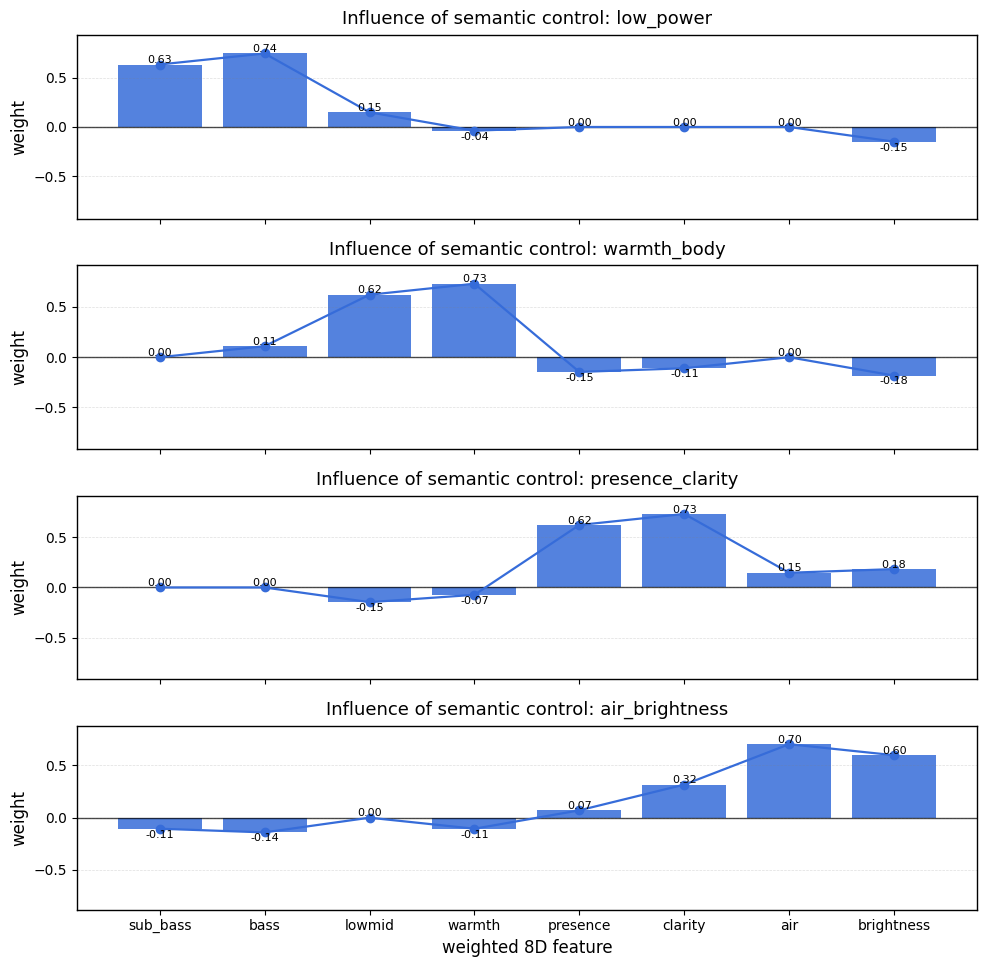

In [7]:
plot_semantic_control_influence(
    CONTROL_BASIS_4D_TO_8D,
    CONTROL_NAMES_4D,
    FEATURE_NAMES_8D,
)
plt.show()

### Интерпретация semantic basis

Heatmap показывает, как 4 semantic controls отображаются в weighted 8D-пространство. Положительные веса усиливают соответствующий 8D-признак, отрицательные — ослабляют.

Например, `low_power` в основном усиливает `sub_bass` и `bass`, `warmth_body` — `lowmid` и `warmth`, `presence_clarity` — `presence` и `clarity`, а `air_brightness` — `air` и `brightness`.

## Batch test на фиксированном dataset

In [8]:
N_STEPS = 25
STEP_SCALE = 0.6
LR = 0.25
STRATEGIES = DEFAULT_STRATEGIES

sessions, curves = run_batch_on_dataset(
    dataset=dataset,
    strategies=STRATEGIES,
    n_steps=N_STEPS,
    step_scale=STEP_SCALE,
    lr=LR,
    init_std=1.0,
    std_decay=0.95,
    min_std=0.15,
    clip_value=2.0,
    pair_seed_base=20_000,
    user_seed_base=10_000,
)

sessions.head()

,user_id,target_mode,strategy,n_steps,initial_distance,final_distance,best_distance,mean_distance,improvement_abs,improvement_pct
0,0,random8d,random,25,2.296546,1.055352,1.055352,1.752149,1.241195,54.046139
1,0,random8d,uncertainty_axis,25,2.296546,0.759396,0.759396,1.506201,1.537150,66.933132
2,0,random8d,semantic_control,25,2.296546,1.006282,1.006282,1.486470,1.290265,56.182825
3,0,random8d,hybrid,25,2.296546,0.622589,0.622589,1.395434,1.673957,72.890194
4,1,random8d,random,25,1.568883,0.801050,0.801050,1.216645,0.767832,48.941355


## Общая сводка по стратегиям и target modes

In [9]:
strategy_summary = summarize_by_strategy(sessions)
strategy_summary.round(4)

,target_mode,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
2,archetype8d,semantic_control,100,1.2159,0.5258,0.2611,0.4105,0.7310,51.0242,23.3556
0,archetype8d,hybrid,100,1.2159,0.5729,0.2975,0.4701,0.7963,46.2786,26.5645
3,archetype8d,uncertainty_axis,100,1.2159,0.5851,0.2793,0.4962,0.8453,45.3001,26.4622
1,archetype8d,random,100,1.2159,0.5899,0.3066,0.5044,0.8400,45.5993,25.9805
7,random8d,uncertainty_axis,100,2.2120,0.9858,0.4159,0.9607,1.5468,56.6639,11.4599
5,random8d,random,100,2.2120,0.9967,0.4021,0.9790,1.5728,55.8002,11.6329
4,random8d,hybrid,100,2.2120,1.0141,0.4371,0.9845,1.5505,55.2770,12.2221
6,random8d,semantic_control,100,2.2120,1.5689,0.5045,1.5288,1.7623,28.7312,16.4385
10,semantic4d,semantic_control,100,1.7319,0.4978,0.2037,0.4034,0.9149,69.3057,13.1061
8,semantic4d,hybrid,100,1.7319,0.6204,0.2293,0.5605,1.0687,62.1722,13.4747


## Win-rate против random baseline

In [10]:
win_rates = win_rates_vs_baseline(sessions, baseline='random')
win_rates.round(4)

,target_mode,strategy,baseline,win_rate_final_distance,win_rate_best_distance
0,archetype8d,hybrid,random,0.58,0.58
1,archetype8d,semantic_control,random,0.54,0.68
2,archetype8d,uncertainty_axis,random,0.50,0.51
3,random8d,hybrid,random,0.49,0.49
4,random8d,semantic_control,random,0.11,0.11
5,random8d,uncertainty_axis,random,0.53,0.51
6,semantic4d,hybrid,random,0.69,0.69
7,semantic4d,semantic_control,random,0.84,0.90
8,semantic4d,uncertainty_axis,random,0.53,0.64


## Графики средней сходимости

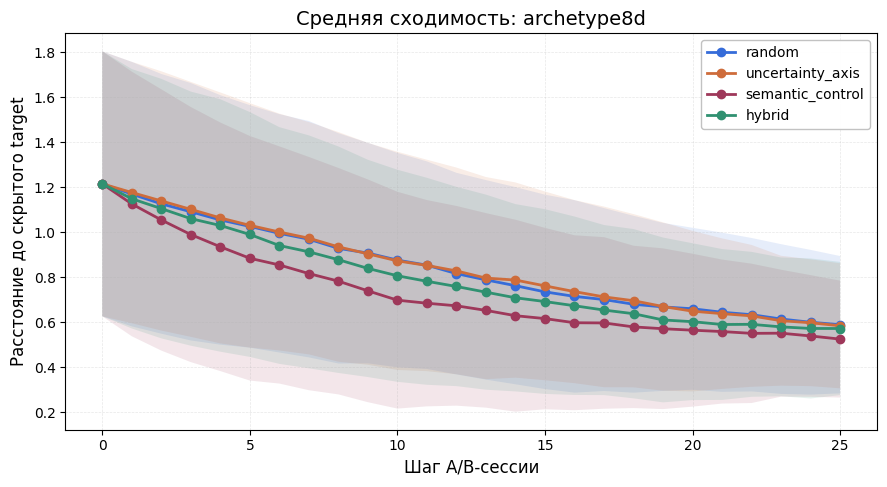

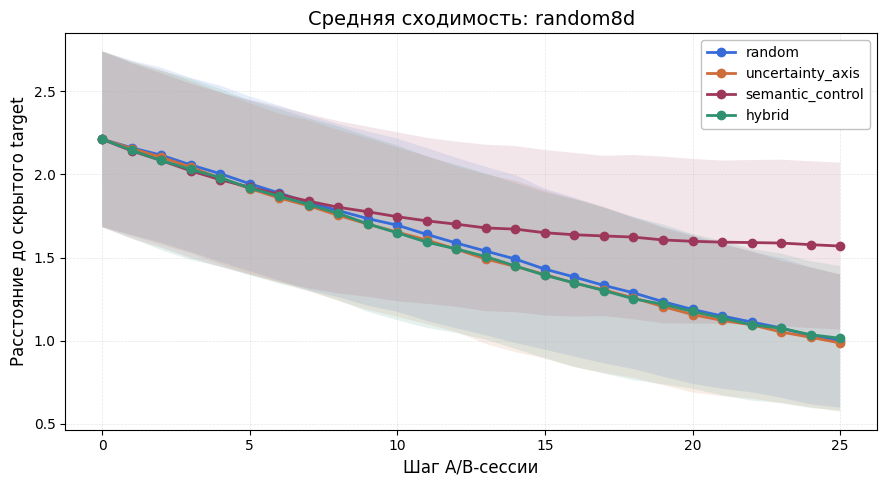

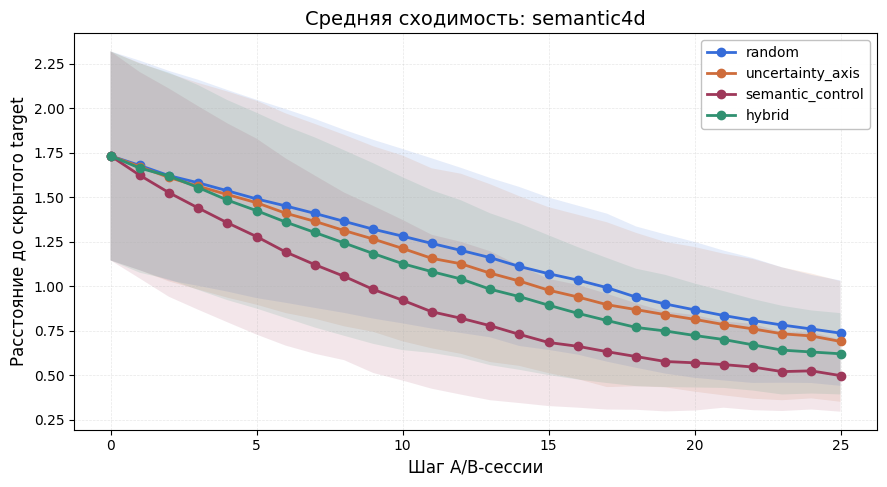

In [11]:
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

for target_mode in sorted(curves.keys()):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')

    for strategy in STRATEGIES:
        curve = curves[target_mode][strategy]
        mean_curve = curve.mean(axis=0)
        std_curve = curve.std(axis=0)
        steps = np.arange(len(mean_curve))

        ax.plot(steps, mean_curve, marker='o', linewidth=2, label=strategy)
        ax.fill_between(steps, mean_curve - std_curve, mean_curve + std_curve, alpha=0.12)

    ax.set_title(f'Средняя сходимость: {target_mode}')
    ax.set_xlabel('Шаг A/B-сессии')
    ax.set_ylabel('Расстояние до скрытого target')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(frameon=True, facecolor='white', edgecolor='0.75', framealpha=0.95)
    plt.tight_layout()

    fig.savefig(FIGURES_DIR / f'v2_dataset_convergence_{target_mode}.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

## Boxplot final_distance

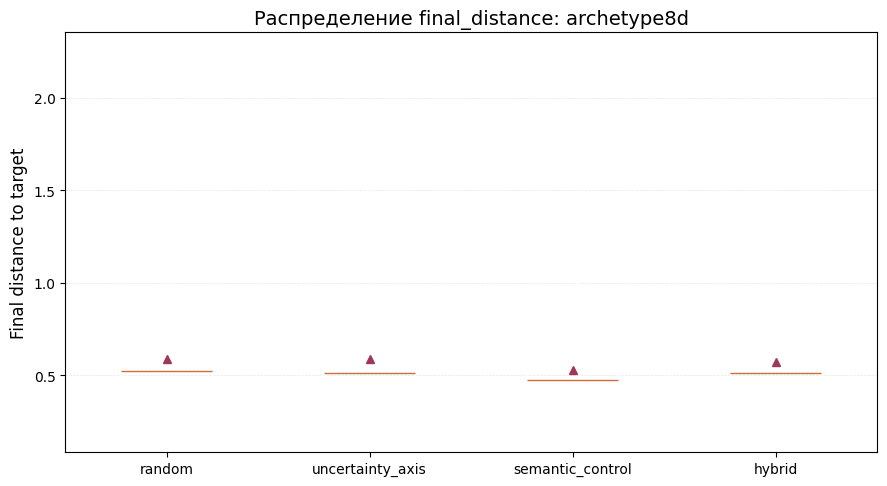

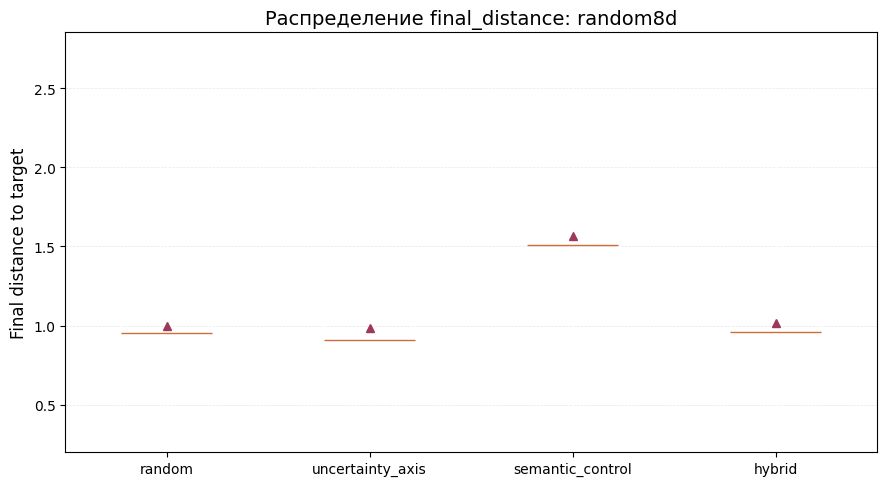

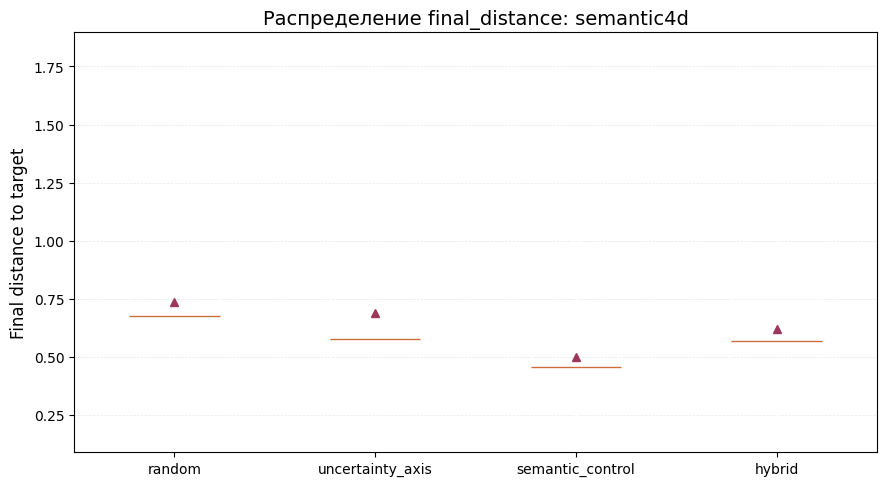

In [13]:
for target_mode in sorted(sessions['target_mode'].unique()):
    subset = sessions[sessions['target_mode'] == target_mode]
    data = [
        subset.loc[subset['strategy'] == strategy, 'final_distance'].values
        for strategy in STRATEGIES
    ]

    fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
    ax.boxplot(data, tick_labels=STRATEGIES, showmeans=True)
    ax.set_title(f'Распределение final_distance: {target_mode}')
    ax.set_ylabel('Final distance to target')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()

    fig.savefig(FIGURES_DIR / f'v2_dataset_boxplot_{target_mode}.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

## Анализ archetype8d по intensity

In [14]:
intensity_cols = ['user_id', 'target_mode', 'main_archetype', 'secondary_archetype', 'is_extreme_archetype', 'intensity_label', 'intensity_value']
intensity_cols = [col for col in intensity_cols if col in dataset.columns]

sessions_with_meta = sessions.merge(dataset[intensity_cols], on=['user_id', 'target_mode'], how='left')

if 'intensity_label' in sessions_with_meta.columns:
    intensity_summary = (
        sessions_with_meta[sessions_with_meta['target_mode'] == 'archetype8d']
        .groupby(['intensity_label', 'strategy'])
        .agg(
            users=('user_id', 'count'),
            mean_final_distance=('final_distance', 'mean'),
            mean_improvement_pct=('improvement_pct', 'mean'),
        )
        .reset_index()
        .sort_values(['intensity_label', 'mean_final_distance'])
    )
    display(intensity_summary.round(4))

,intensity_label,strategy,users,mean_final_distance,mean_improvement_pct
2,extreme,semantic_control,16,0.8232,57.6705
0,extreme,hybrid,16,0.8737,56.9149
3,extreme,uncertainty_axis,16,0.9341,52.7577
1,extreme,random,16,0.9373,52.1928
6,mild,semantic_control,20,0.4110,37.7764
7,mild,uncertainty_axis,20,0.4570,28.2548
5,mild,random,20,0.4714,26.7945
4,mild,hybrid,20,0.4883,24.0316
10,moderate,semantic_control,28,0.4446,50.0803
9,moderate,random,28,0.4812,46.2167


## Детальный анализ: где выигрывает semantic control

Ниже результаты разбиваются по типам synthetic users: `target_mode`, `intensity_label` и `main_archetype`. Это помогает понять, на каких пользовательских сценариях semantic-направления действительно полезны.


In [15]:
sessions_with_meta = merge_sessions_with_user_metadata(sessions, dataset)
sessions_with_meta.head()


,user_id,target_mode,strategy,n_steps,initial_distance,final_distance,best_distance,mean_distance,improvement_abs,improvement_pct,main_archetype,secondary_archetype,is_extreme_archetype,intensity_label,intensity_value
0,0,random8d,random,25,2.296546,1.055352,1.055352,1.752149,1.241195,54.046139,none,none,False,random,1.0
1,0,random8d,uncertainty_axis,25,2.296546,0.759396,0.759396,1.506201,1.537150,66.933132,none,none,False,random,1.0
2,0,random8d,semantic_control,25,2.296546,1.006282,1.006282,1.486470,1.290265,56.182825,none,none,False,random,1.0
3,0,random8d,hybrid,25,2.296546,0.622589,0.622589,1.395434,1.673957,72.890194,none,none,False,random,1.0
4,1,random8d,random,25,1.568883,0.801050,0.801050,1.216645,0.767832,48.941355,none,none,False,random,1.0


### Анализ по target_mode


In [16]:
target_mode_group_summary = summarize_by_group(
    sessions_with_meta,
    group_cols=['target_mode'],
)
target_mode_winners = winners_by_group(
    target_mode_group_summary,
    group_cols=['target_mode'],
    metric='mean_final_distance',
)
display(target_mode_group_summary.round(4))
display(target_mode_winners.round(4))


,target_mode,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
2,archetype8d,semantic_control,100,1.2159,0.5258,0.2611,0.4105,0.7310,51.0242,23.3556
0,archetype8d,hybrid,100,1.2159,0.5729,0.2975,0.4701,0.7963,46.2786,26.5645
3,archetype8d,uncertainty_axis,100,1.2159,0.5851,0.2793,0.4962,0.8453,45.3001,26.4622
1,archetype8d,random,100,1.2159,0.5899,0.3066,0.5044,0.8400,45.5993,25.9805
7,random8d,uncertainty_axis,100,2.2120,0.9858,0.4159,0.9607,1.5468,56.6639,11.4599
5,random8d,random,100,2.2120,0.9967,0.4021,0.9790,1.5728,55.8002,11.6329
4,random8d,hybrid,100,2.2120,1.0141,0.4371,0.9845,1.5505,55.2770,12.2221
6,random8d,semantic_control,100,2.2120,1.5689,0.5045,1.5288,1.7623,28.7312,16.4385
10,semantic4d,semantic_control,100,1.7319,0.4978,0.2037,0.4034,0.9149,69.3057,13.1061
8,semantic4d,hybrid,100,1.7319,0.6204,0.2293,0.5605,1.0687,62.1722,13.4747


,target_mode,winner_strategy,users,winner_mean_final_distance
0,semantic4d,semantic_control,100,0.4978
1,archetype8d,semantic_control,100,0.5258
2,random8d,uncertainty_axis,100,0.9858


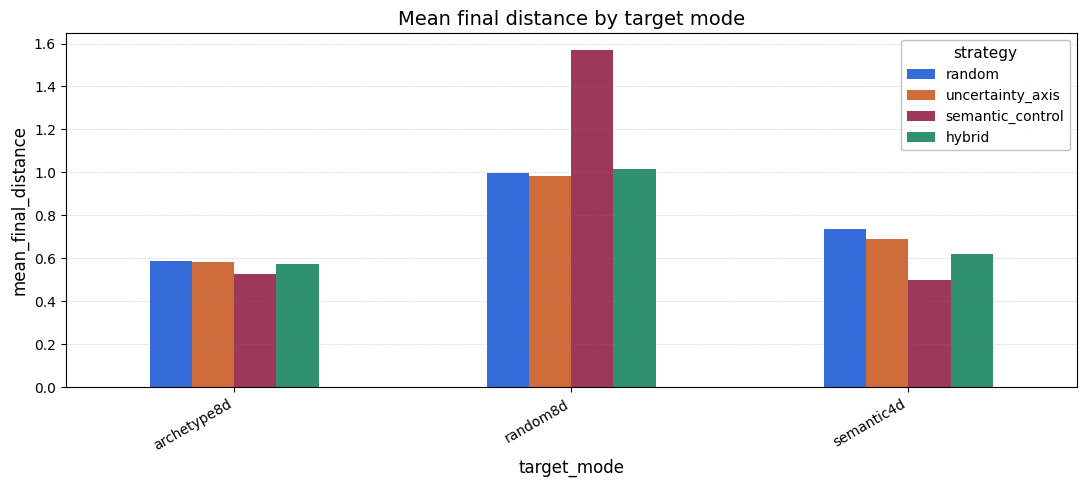

In [17]:
fig, ax = plot_group_metric_bars(
    target_mode_group_summary,
    group_col='target_mode',
    metric='mean_final_distance',
    title='Mean final distance by target mode',
)
fig.savefig(FIGURES_DIR / 'v2_group_target_mode_mean_final_distance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


### Анализ по intensity_label для archetype8d


In [18]:
archetype_sessions = sessions_with_meta[
    sessions_with_meta['target_mode'] == 'archetype8d'
].copy()

if 'intensity_label' in archetype_sessions.columns:
    intensity_group_summary = summarize_by_group(
        archetype_sessions,
        group_cols=['intensity_label'],
    )
    intensity_winners = winners_by_group(
        intensity_group_summary,
        group_cols=['intensity_label'],
        metric='mean_final_distance',
    )
    display(intensity_group_summary.round(4))
    display(intensity_winners.round(4))
else:
    print('No intensity_label column found.')


,intensity_label,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
2,extreme,semantic_control,16,1.9486,0.8232,0.4651,0.7560,1.2199,57.6705,14.5678
0,extreme,hybrid,16,1.9486,0.8737,0.5863,0.8063,1.3026,56.9149,15.4650
3,extreme,uncertainty_axis,16,1.9486,0.9341,0.4606,0.8968,1.3926,52.7577,9.2405
1,extreme,random,16,1.9486,0.9373,0.5635,0.8903,1.4091,52.1928,18.5672
6,mild,semantic_control,20,0.7164,0.4110,0.1068,0.2648,0.4619,37.7764,22.5735
7,mild,uncertainty_axis,20,0.7164,0.4570,0.0702,0.3322,0.5313,28.2548,28.2952
5,mild,random,20,0.7164,0.4714,0.1179,0.3238,0.5379,26.7945,30.7837
4,mild,hybrid,20,0.7164,0.4883,0.1200,0.3393,0.5449,24.0316,33.2149
10,moderate,semantic_control,28,1.0135,0.4446,0.1364,0.3207,0.5884,50.0803,24.0924
9,moderate,random,28,1.0135,0.4812,0.1384,0.4042,0.6932,46.2167,29.1498


,intensity_label,winner_strategy,users,winner_mean_final_distance
0,mild,semantic_control,20,0.4110
1,moderate,semantic_control,28,0.4446
2,strong,semantic_control,36,0.5207
3,extreme,semantic_control,16,0.8232


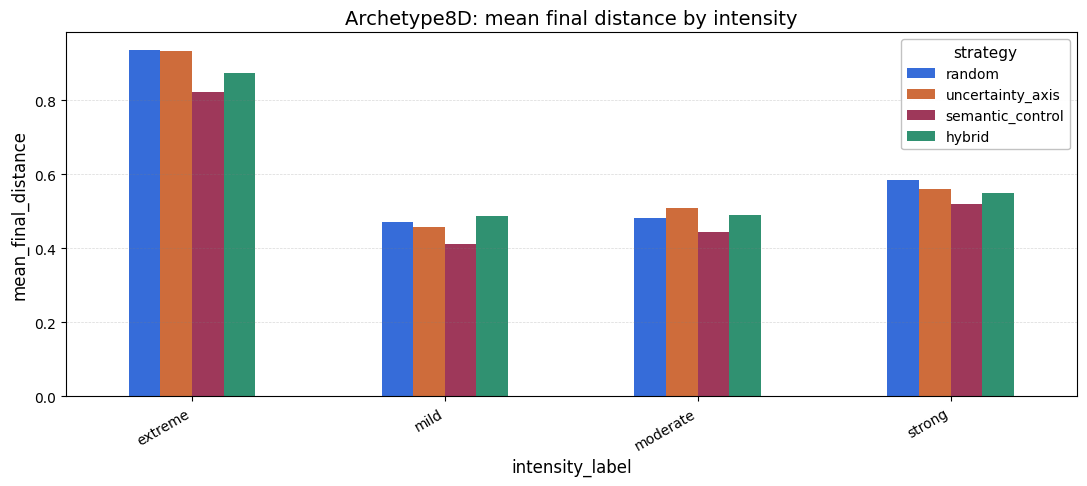

In [19]:
if 'intensity_label' in archetype_sessions.columns:
    fig, ax = plot_group_metric_bars(
        intensity_group_summary,
        group_col='intensity_label',
        metric='mean_final_distance',
        title='Archetype8D: mean final distance by intensity',
    )
    fig.savefig(FIGURES_DIR / 'v2_archetype_intensity_mean_final_distance.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


,intensity_label,strategy,baseline,win_rate_final_distance,n_users
0,extreme,uncertainty_axis,random,0.4375,16
1,extreme,semantic_control,random,0.5625,16
2,extreme,hybrid,random,0.6250,16
3,mild,uncertainty_axis,random,0.4500,20
4,mild,semantic_control,random,0.5500,20
5,mild,hybrid,random,0.5000,20
6,moderate,uncertainty_axis,random,0.4643,28
7,moderate,semantic_control,random,0.4643,28
8,moderate,hybrid,random,0.5000,28
9,strong,uncertainty_axis,random,0.5833,36


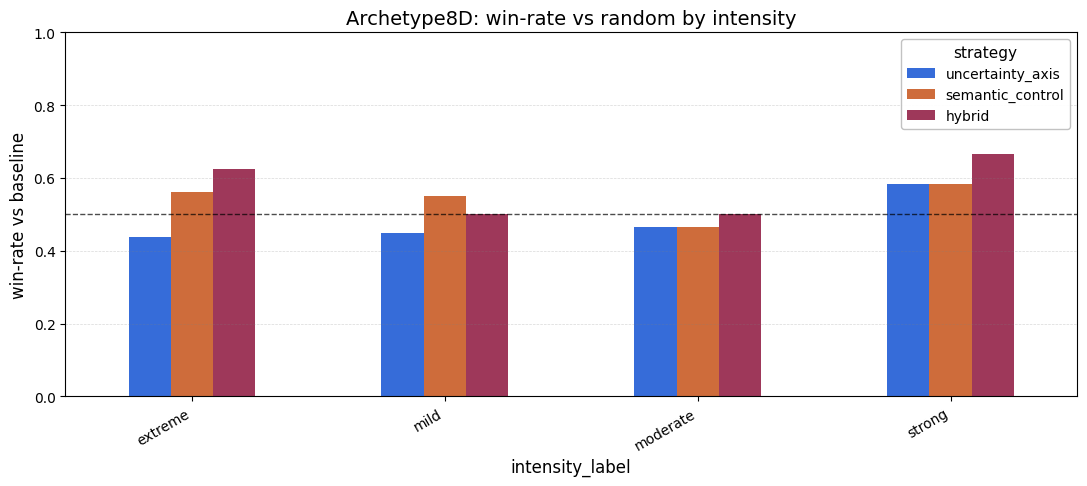

In [20]:
if 'intensity_label' in archetype_sessions.columns:
    intensity_win_rates = win_rates_vs_baseline_by_group(
        archetype_sessions,
        group_cols=['intensity_label'],
        baseline='random',
        metric='final_distance',
    )
    display(intensity_win_rates.round(4))

    fig, ax = plot_win_rate_bars(
        intensity_win_rates,
        group_col='intensity_label',
        metric_col='win_rate_final_distance',
        title='Archetype8D: win-rate vs random by intensity',
    )
    fig.savefig(FIGURES_DIR / 'v2_archetype_intensity_win_rate_final.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


### Анализ по main_archetype


In [21]:
if 'main_archetype' in archetype_sessions.columns:
    main_archetype_group_summary = summarize_by_group(
        archetype_sessions,
        group_cols=['main_archetype'],
    )
    main_archetype_winners = winners_by_group(
        main_archetype_group_summary,
        group_cols=['main_archetype'],
        metric='mean_final_distance',
    )
    display(main_archetype_group_summary.round(4))
    display(main_archetype_winners.round(4))
else:
    print('No main_archetype column found.')


,main_archetype,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
2,bass_lover,semantic_control,9,1.0007,0.4684,0.1340,0.2969,0.6335,48.6502,19.0315
0,bass_lover,hybrid,9,1.0007,0.5033,0.1050,0.3562,0.6338,45.1317,17.0766
3,bass_lover,uncertainty_axis,9,1.0007,0.5365,0.1543,0.4126,0.7211,44.5716,12.2582
1,bass_lover,random,9,1.0007,0.5481,0.1811,0.4559,0.6854,44.4175,9.6064
6,basshead,semantic_control,8,1.4940,0.4875,0.2330,0.4276,0.8592,67.1902,12.9685
4,basshead,hybrid,8,1.4940,0.5803,0.2078,0.5227,0.9487,60.4080,12.5322
7,basshead,uncertainty_axis,8,1.4940,0.6493,0.2355,0.5920,1.0319,56.1850,11.2327
5,basshead,random,8,1.4940,0.6845,0.2741,0.6151,1.0336,54.0237,15.0483
10,bright,semantic_control,2,0.7020,0.4113,0.2289,0.2690,0.4305,38.6093,41.0009
9,bright,random,2,0.7020,0.4944,0.0377,0.3168,0.5367,29.2801,4.2895


,main_archetype,winner_strategy,users,winner_mean_final_distance
0,neutral,hybrid,6,0.3603
1,bright,semantic_control,2,0.4113
2,warm,semantic_control,7,0.4238
3,mid_forward,semantic_control,13,0.4396
4,soft_dark,semantic_control,11,0.4498
5,detail_focused,semantic_control,11,0.4506
6,bass_lover,semantic_control,9,0.4684
7,v_shape,random,6,0.4832
8,basshead,semantic_control,8,0.4875
9,sparkle_lover,hybrid,12,0.5341


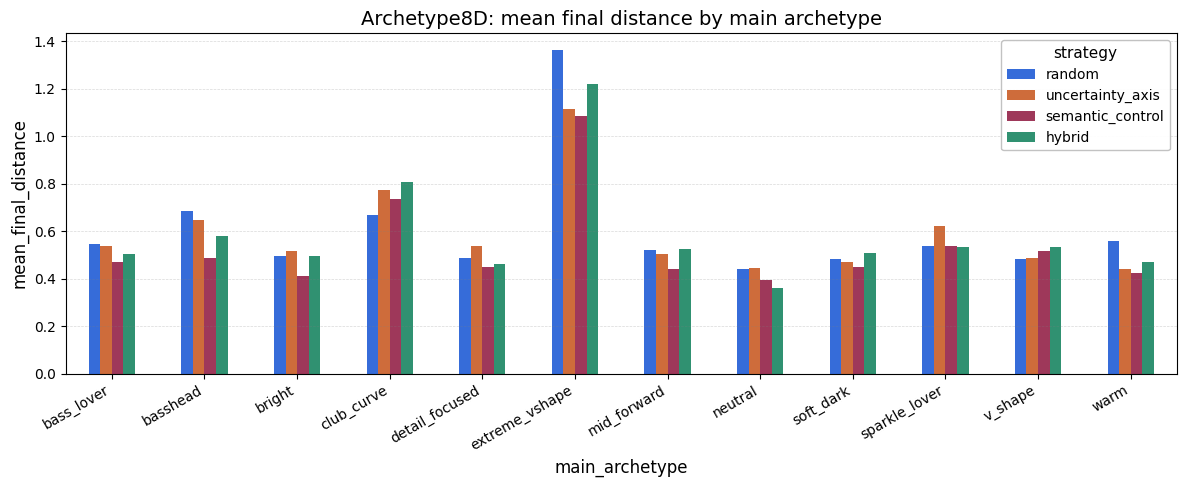

In [22]:
if 'main_archetype' in archetype_sessions.columns:
    fig, ax = plot_group_metric_bars(
        main_archetype_group_summary,
        group_col='main_archetype',
        metric='mean_final_distance',
        title='Archetype8D: mean final distance by main archetype',
        figsize=(12, 5),
    )
    fig.savefig(FIGURES_DIR / 'v2_archetype_main_archetype_mean_final_distance.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


In [23]:
if 'main_archetype' in archetype_sessions.columns:
    archetype_win_rates = win_rates_vs_baseline_by_group(
        archetype_sessions,
        group_cols=['main_archetype'],
        baseline='random',
        metric='final_distance',
    )
    display(archetype_win_rates.round(4))


,main_archetype,strategy,baseline,win_rate_final_distance,n_users
0,bass_lover,uncertainty_axis,random,0.5556,9
1,bass_lover,semantic_control,random,0.5556,9
2,bass_lover,hybrid,random,0.5556,9
3,basshead,uncertainty_axis,random,0.5000,8
4,basshead,semantic_control,random,0.8750,8
5,basshead,hybrid,random,0.7500,8
6,bright,uncertainty_axis,random,0.5000,2
7,bright,semantic_control,random,0.5000,2
8,bright,hybrid,random,0.5000,2
9,club_curve,uncertainty_axis,random,0.3333,9


### Интерпретация детального анализа

Этот блок нужен, чтобы понять не только средний результат стратегии, но и её поведение на разных типах synthetic users. Если `semantic_control` выигрывает на `semantic4d` и на части `archetype8d`-пользователей, но проигрывает на `random8d`, это означает, что semantic controls полезны именно для пользователей с музыкально-семантической структурой предпочтений.

Анализ по `intensity_label` дополнительно показывает, выдерживает ли стратегия сильные и экстремальные предпочтения. Анализ по `main_archetype` показывает, для каких типажей пользователей semantic-направления наиболее полезны: например, basshead, warm, bright, v_shape и т.д.


## Сохранение результатов

In [24]:
METRICS_DIR = PROJECT_ROOT / 'outputs' / 'metrics'
METRICS_DIR.mkdir(parents=True, exist_ok=True)

save_batch_outputs(
    sessions=sessions,
    strategy_summary=strategy_summary,
    win_rates=win_rates,
    output_dir=METRICS_DIR,
    prefix='notebook_v2_dataset_based',
)

if 'sessions_with_meta' in globals():
    sessions_with_meta.to_csv(METRICS_DIR / 'notebook_v2_dataset_based_sessions_with_meta.csv', index=False)


# Save detailed group analysis tables if they were created.
if 'target_mode_group_summary' in globals():
    target_mode_group_summary.to_csv(METRICS_DIR / 'notebook_v2_target_mode_group_summary.csv', index=False)
if 'target_mode_winners' in globals():
    target_mode_winners.to_csv(METRICS_DIR / 'notebook_v2_target_mode_winners.csv', index=False)
if 'intensity_group_summary' in globals():
    intensity_group_summary.to_csv(METRICS_DIR / 'notebook_v2_archetype_intensity_group_summary.csv', index=False)
if 'intensity_win_rates' in globals():
    intensity_win_rates.to_csv(METRICS_DIR / 'notebook_v2_archetype_intensity_win_rates.csv', index=False)
if 'main_archetype_group_summary' in globals():
    main_archetype_group_summary.to_csv(METRICS_DIR / 'notebook_v2_archetype_main_group_summary.csv', index=False)
if 'archetype_win_rates' in globals():
    archetype_win_rates.to_csv(METRICS_DIR / 'notebook_v2_archetype_main_win_rates.csv', index=False)

print('Saved metrics to:', METRICS_DIR)

Saved metrics to: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\metrics


## Вывод по детальному анализу synthetic users

Детальный анализ по типам пользователей показал, что эффективность стратегий Pair Generator зависит от структуры скрытых предпочтений. В режиме `random8d`, где target-вектор произволен во всём weighted 8D-пространстве, лучшей стратегией стала `uncertainty_axis`, а `semantic_control` ожидаемо показал худший результат, так как ограничивает поиск заранее заданными semantic-направлениями.

В режимах `semantic4d` и `archetype8d` лучшей стратегией стала `semantic_control`. Это подтверждает гипотезу о том, что semantic controls полезны для пользователей, предпочтения которых имеют музыкально-семантическую структуру.

Анализ по интенсивности показал, что `semantic_control` имеет наименьшее среднее final distance во всех группах: `mild`, `moderate`, `strong` и `extreme`. При этом для `strong` и `extreme` пользователей стратегия `hybrid` местами показывает более высокий win-rate относительно random baseline, что указывает на потенциальную пользу комбинирования semantic-направлений с более общей exploration-компонентой.

Анализ по основным архетипам показал, что `semantic_control` особенно хорошо работает для пользователей типа `basshead`, `bass_lover`, `detail_focused` и `extreme_vshape`. Например, для `basshead` стратегия `semantic_control` достигла меньшего mean_final_distance, чем random baseline, и выиграла у него в 87.5% сессий. При этом для архетипа `club_curve` random baseline оказался сильнее, что указывает на недостаточную выразительность текущей 4D semantic basis для некоторых пользовательских типажей.

Таким образом, semantic controls являются полезной и интерпретируемой стратегией генерации A/B-вопросов для реалистичных пользователей, но текущую semantic basis целесообразно расширить дополнительными направлениями, например для более точного описания club/bass-oriented профилей.